### Práctica 2: Propiedades estadísticas del lenguaje y Diversidad
#### 1. Verificación empírica de la Ley de Zipf
Verificar si la ley de Zipf se cumple en los siguientes casos:

1.   En un lenguaje artificial creado por ustedes.


*   Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido


       *   Nota: Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.


*   Obtengan las frecuencias de las palabras generadas para este texto artificial


2.   Alguna lengua de bajos recursos digitales (low-resourced language)


*  Busca un corpus de libre acceso en alguna lengua de bajos recursos digitales
*   Obten las frecuencias de sus palabras

En ambos casos realiza lo siguiente:


*   Estima el parámetro $\alpha$
 que mejor se ajuste a la curva
*   Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).


    *   Incluye la recta aproximada por $\alpha$
*   ¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.

[!TIP] Puedes utilizar los corpus del paquete py-elotl






In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import string
from collections import Counter
#Aquí colocaré todas las librerías que use para el ejercicio número uno

In [2]:
#Creamos un minicorpus haciendo uso de random seed para poder replicar el como nos lo fabrica el código para la entrega
random.seed(42)
vocabulario=string.ascii_lowercase + " "#Definimos el vocabulario con ayuda de las letras conocidas a través de string

pesos = [1] * 26 + [5]#Asignamos pesos (probabilidades) a cada letra y al espacio
palabras = random.choices(vocabulario,weights=pesos,k=100000)#Formamos las palabras con random choices y formamos 100000 elementos entre espacios y palabras
corpus="".join(palabras)#Formamos el corpus con dichos 100000 elementos junto a los espacios seleccionados
lista=corpus.split()#Generamos una lista con el corpus generado
df=pd.DataFrame(lista,columns=["palabra"])#Llamamos df a la tabla de las palabras contenidas en el corpus
frecuencias=df['palabra'].value_counts().reset_index()
frecuencias.columns = ['Palabra', 'Frecuencia']
frecuencias['rank']=frecuencias['Palabra'].rank(ascending=False,method='first')
print(frecuencias.head(10))

  Palabra  Frecuencia    rank
0       u         106  2362.0
1       y         102   801.0
2       d         100  8943.0
3       e         100  8545.0
4       n          96  5087.0
5       r          92  3494.0
6       f          91  8168.0
7       t          86  2751.0
8       c          86  9359.0
9       s          85  3105.0


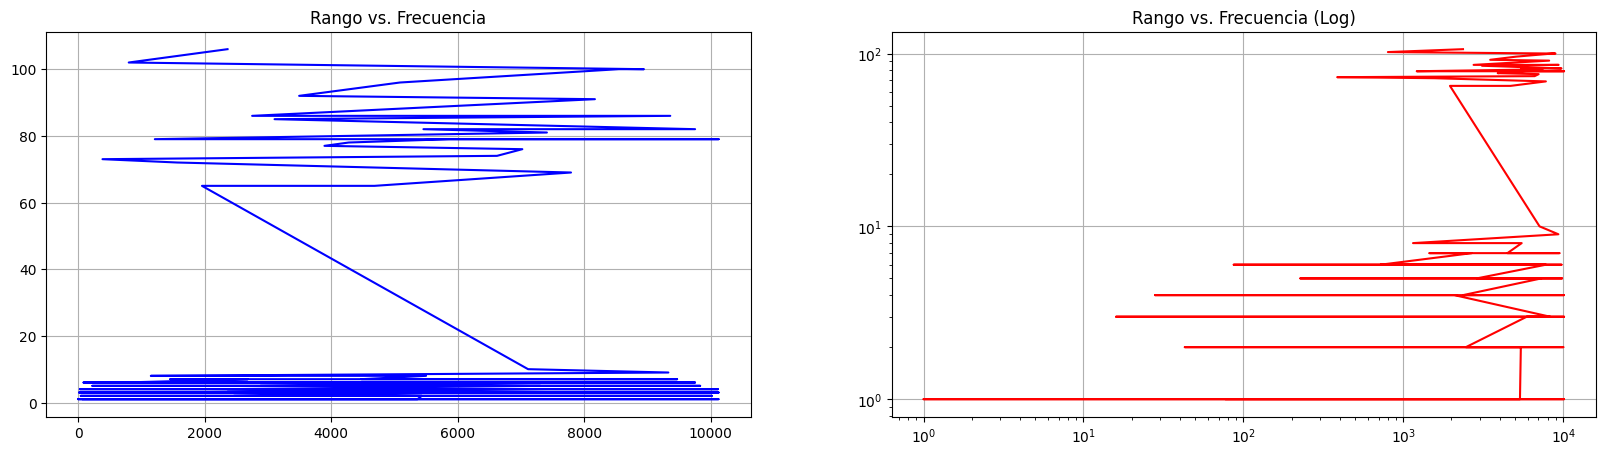

In [3]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title("Rango vs. Frecuencia")
plt.plot(frecuencias['rank'],frecuencias['Frecuencia'],color='blue')
plt.grid()
plt.subplot(1,2,2)
plt.title("Rango vs. Frecuencia (Log)")
plt.loglog(frecuencias['rank'],frecuencias['Frecuencia'],color='red')
plt.grid()
plt.show()

In [4]:
!pip install datasets

### Usando un corpus de elotl o de texto real



In [5]:
!pip install elotl  
#Instalamos la paquetería de elotl

In [6]:
import elotl.corpus
print("Name\t\tDescription")
list_of_corpus = elotl.corpus.list_of_corpus()
for row in list_of_corpus:
    print(row)#Usamos la función proporciondad por el mismo elotl para ver el contenido de los corpus posibles

Name		Description
['axolotl', 'Is a Spanish-Nahuatl parallel corpus']
['tsunkua', 'Is a Spanish-Otomí parallel corpus']
['kolo', 'Is a Spanish-Mixteco parallel corpus']


In [7]:
tsunkua = elotl.corpus.load('tsunkua')#Tomamos el del Otomí para este ejemplo

In [8]:
from datasets import Dataset
#Vamos a separar cada una de las dos listas que nos ofrece el corpus al ser una lista de listas esto podría traer problemas
spanish = [entry[0] for entry in tsunkua if isinstance(entry, list) and len(entry) > 0]#Extraemos solo las del español
otomi =[entry[1] for entry in tsunkua if isinstance(entry,list)and len(entry)>0]#En esta solo extraemos las palabras en otomí
todo=spanish+otomi#Ahora hacemos una suma de todas las palabras del corpus
# Creamos el Dataset de Hugging Face donde cada fila tiene una cadena de texto en la columna 'text'
datatsunkua = Dataset.from_dict({"text": todo})
print(datatsunkua)

C:\Users\luisi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['text'],
    num_rows: 9926
})


In [9]:
corpus_2 = datatsunkua.take(9000)#Tomamos 9000 elementos de los totales de nuestro dataset asignandolo a corpus
 #A partir de aquí usaremos las funciones vistas en clase

In [10]:
import re

def normalize_corpus(example):
    example["text"] = re.sub(r"[\W]", " ", example["text"])
    example["text"] = example["text"].lower()
    return example

In [11]:
from datasets.iterable_dataset import IterableDataset


def count_words(corpus: IterableDataset) -> Counter:
    word_counts = Counter()
    normalized_corpus = corpus.map(normalize_corpus)
    for row in normalized_corpus:
        text = row["text"]
        word_counts.update(text.split())
    return word_counts

In [12]:
words = count_words(corpus_2)#Con la conversión hecha podemos mapear las palabras del corpus

Map: 100%|████████████████████████████████████████████████████████████████| 9000/9000 [00:02<00:00, 3168.07 examples/s]


In [13]:
words.most_common(10)#Verificamos las 10 palabras más comunes

[('ra', 4824),
 ('a', 4096),
 ('ya', 3462),
 ('de', 3217),
 ('y', 1976),
 ('i', 1794),
 ('bi', 1725),
 ('mi', 1638),
 ('los', 1598),
 ('que', 1543)]

In [14]:
import pandas as pd


def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

In [15]:
corpus_freqs = counter_to_pandas(words)

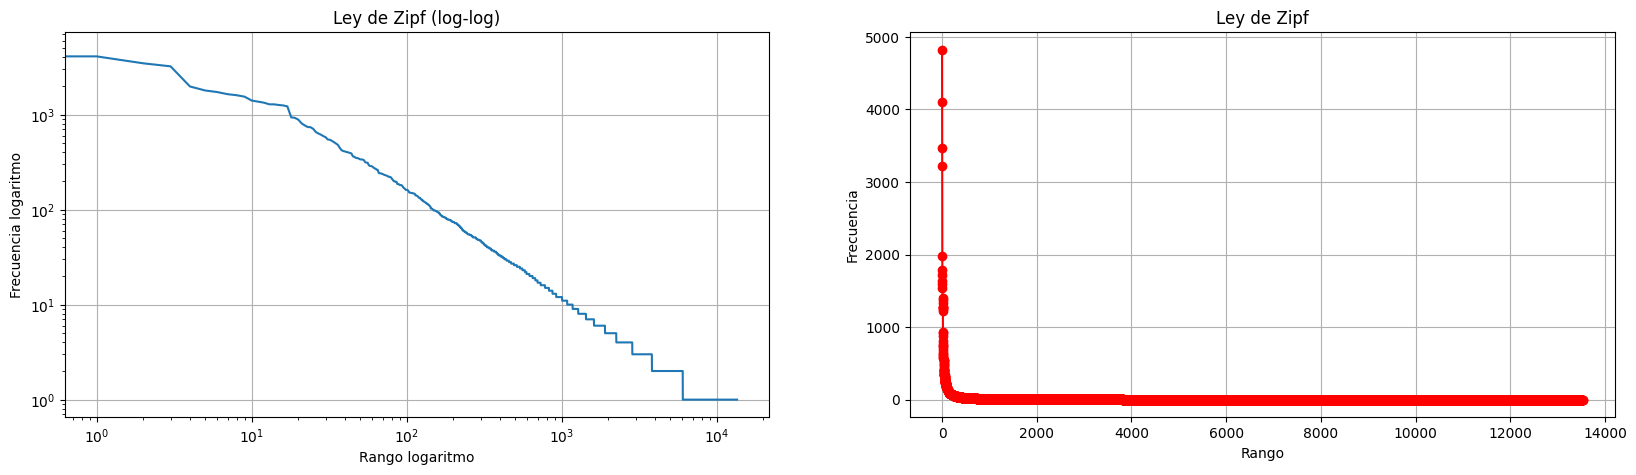

In [16]:
#Hacemos el plot como en clase de ambos en este corpus
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
corpus_freqs["count"].plot(loglog=True, legend=False)
plt.title("Ley de Zipf (log-log)")
plt.xlabel("Rango logaritmo")
plt.ylabel("Frecuencia logaritmo")
plt.grid()
plt.subplot(1,2,2)
corpus_freqs["count"].plot(legend=False,color='red', marker="o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

### ANÁLISIS

A diferencia del lenguaje artificial (aleatorio) vemos un comportamiento casi similar al que vimos en clase con el corpus de elotl siguiendo un comportamiento similar al de cualquier corpus, mientras que el artifical no sigue dicha reglas con palabras formadas aleatoriamente y probabilidades también aleatorias donde todas las palabras tienen la probabilidad de aparecer por lo menos una vez y los espacios cada 5 de ellas

In [17]:
import numpy as np
from scipy.optimize import minimize

# Obtenemos los ranks y las frecuencias del corpus
# +1 para hacer que los ranks inicien en 1 y no en 0
ranks = np.array(corpus_freqs.index) + 1
frequencies = np.array(corpus_freqs["count"])
ranks2 = np.array(frecuencias.index) + 1
frequencies2 = np.array(frecuencias["Frecuencia"])


def zipf_minimization_objective(
    alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray
) -> np.float64:
    """
    Calculate the sum of squared errors for Zipf's law fit.

    Parameters
    ----------
    alpha : np.float64
        The exponent parameter to optimize in Zipf's law
    word_ranks : np.ndarray
        Array of word ranks (1 = most frequent word)
    word_frequencies : np.ndarray
        Array of observed word frequencies

    Returns
    -------
    np.float64
        Sum of squared errors between log frequencies and Zipf's law prediction
    """
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)


# Parámeto alfa inicial
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective, initial_alpha_guess, args=(ranks, frequencies)
)
optimization_result2 = minimize(
    zipf_minimization_objective, initial_alpha_guess, args=(ranks2, frequencies2)
)
estimated_alpha = optimization_result.x[0]
estimated_alpha2 = optimization_result2.x[0]
mean_squared_error = zipf_minimization_objective(estimated_alpha, ranks, frequencies)
mean_squared_error2 = zipf_minimization_objective(estimated_alpha2, ranks2, frequencies2)
print(
    f"Estimated alpha: {estimated_alpha:.4f}\nMean Squared Error: {mean_squared_error:.4f}"
    f"\nEstimated alpha2: {estimated_alpha2:.4f}\nMean Squared Error2: {mean_squared_error2:.4f}"
)

Estimated alpha: 0.9166
Mean Squared Error: 784.8359
Estimated alpha2: 0.5537
Mean Squared Error2: 1548.6751


In [18]:
def plot_generate_zipf(alpha: np.float64, ranks: np.ndarray, freqs: np.ndarray) -> None:
    plt.plot(
        np.log(ranks),
        np.log(freqs[0]) - alpha * np.log(ranks),
        color="r",
        label="Aproximación Zipf",
    )

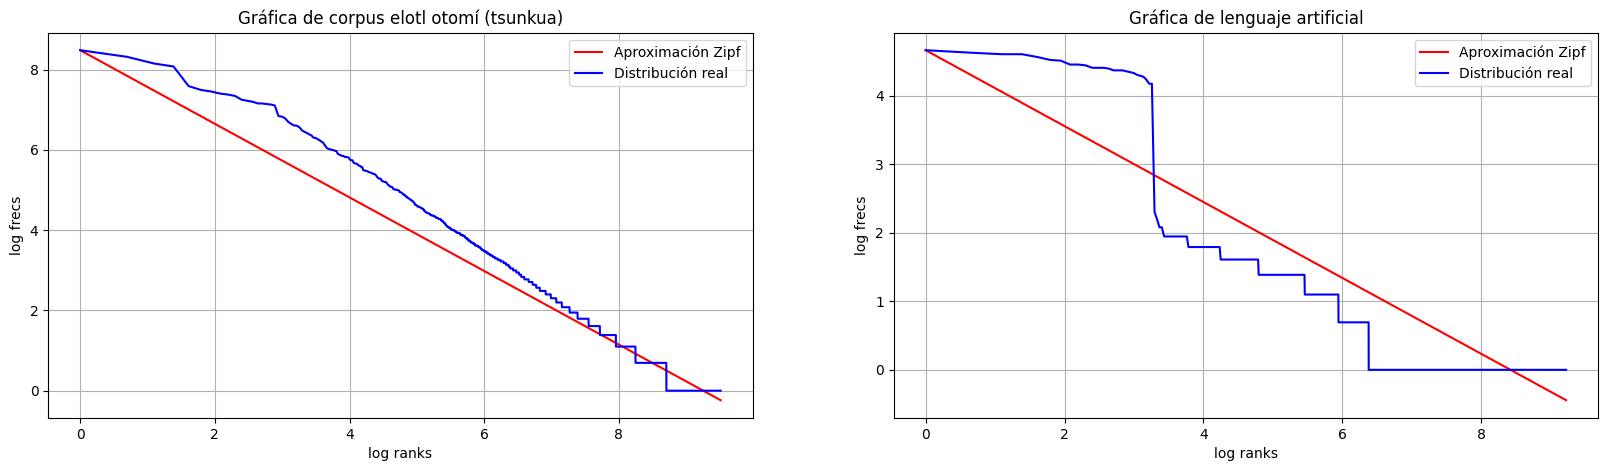

In [19]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title("Gráfica de corpus elotl otomí (tsunkua)")
plot_generate_zipf(estimated_alpha, ranks, frequencies)
plt.plot(np.log(ranks), np.log(frequencies), color="b", label="Distribución real")
plt.xlabel("log ranks")
plt.ylabel("log frecs")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid()
plt.subplot(1,2,2)
plt.title("Gráfica de lenguaje artificial")
plot_generate_zipf(estimated_alpha2, ranks2, frequencies2)
plt.plot(np.log(ranks2), np.log(frequencies2), color="b", label="Distribución real")
plt.xlabel("log ranks")
plt.ylabel("log frecs")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

### La ley de Zipf en los lenguajes naturales y artificiales
En este caso observamos que en cada gráfica se tiene una aproximación de la ley de zipf mejor en el caso del lenguaje natural que el artificial  siguiendo la tendencia esperada, y aunque el lenguaje artificial pareciera tomar un comportamiento similar, nos presenta un alejamiento mayor a la de la aproximación aun habiendo obtenido los mejores valores para aproximación de $\alpha$ observando que dicho sistema de lenguaje no sigue los principios que debería seguir uno natural con las reglas y comportamientos debidos indicando un error en la formación del mismo.

Además se nos da un indicativo en la forma de las primeras gráficas mostrando un comportamiento extraño en las mismas sin tener un orden claro como la que si tienen los sistemas del corpus basado en un lenguaje real.

 ### 2.Visualizando la diversidad lingüística de México
  

1. Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México
   * Usa las columnas "longitude" y "latitude"
2. Realiza un plot de las lenguas por región de un mapa
   * Utiliza un color por familia linguistica en el mapa
3. Haz lo mismo para otro país del mundo
Responde las preguntas:

    * ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?
    * ¿Cuál es la zona que dirias que tiene mayor diversidad en México?
[!TIP] Utiliza la biblioteca plotly para crear mapa interactivos.

In [20]:
import os
DATA_PATH = "data" #La carpeta data está dentro de la carpeta de la practica
LANG_GEO_FILE = "languages_and_dialects_geo.csv"
LANGUOID_FILE = "languoid.csv"

In [21]:
languages = pd.read_csv(os.path.join(DATA_PATH, LANG_GEO_FILE))
languages.head()

,glottocode,name,isocodes,level,macroarea,latitude,longitude
0,3adt1234,3Ad-Tekles,NaN,dialect,Africa,NaN,NaN
1,aala1237,Aalawa,NaN,dialect,Papunesia,NaN,NaN
2,aant1238,Aantantara,NaN,dialect,Papunesia,NaN,NaN
3,aari1239,Aari,aiw,language,Africa,5.95034,36.5721
4,aari1240,Aariya,aay,language,Eurasia,NaN,NaN


In [22]:
languoids = pd.read_csv(os.path.join(DATA_PATH, LANGUOID_FILE))
languoids.head()

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [23]:
#Utilizamos la actividad hecha en clase para filtrar las lenguas por latitud y longitud de México
# Mejorar estas coordenadas
min_lat = 14.5
max_lat = 32.7
min_long = -118.4
max_long = -86.8

mexico_languages = languages[
    (languages["latitude"] >= min_lat)
    & (languages["latitude"] <= max_lat)
    & (languages["longitude"] >= min_long)
    & (languages["longitude"] <= max_long)
]

In [24]:
# Reconstrucción de linajes usando grafos locales (languoid.csv)
languoids_dict = languoids.set_index("id").to_dict("index")


def reconstruir_linaje(glottocode):
    """Sube por el árbol genealógico desde la lengua hasta la familia raíz."""
    linaje = []
    current_id = glottocode

    # Mientras el ID actual exista y no sea nulo (NaN)
    while pd.notna(current_id) and current_id in languoids_dict:
        nodo = languoids_dict[current_id]

        # Filtramos lenguas artificiales o "bookkeeping"
        if nodo.get("bookkeeping") or nodo.get("name") == "Unclassifiable":
            return "Unclassifiable"

        # Insertamos el nombre al inicio de la lista para mantener el orden (Raíz -> Lengua)
        linaje.insert(0, str(nodo["name"]))

        # Subimos al nodo padre
        current_id = nodo["parent_id"]

    return " > ".join(linaje)

In [25]:
# Aplicamos la función a nuestras lenguas de México
mexico_languages = mexico_languages.copy()
mexico_languages["tree"] = mexico_languages["glottocode"].apply(reconstruir_linaje)

# Filtramos las que no se pudieron clasificar
df = mexico_languages[~mexico_languages["tree"].isin(["", "Unclassifiable"])].copy()

# Extraemos la familia lingüística (la primera palabra del linaje)
df["Family"] = df["tree"].str.split().str[0]
df.set_index("glottocode", inplace=True)
df.head()

,name,isocodes,level,macroarea,latitude,longitude,tree,Family
glottocode,,,,,,,,
acat1239,Acatepec Me'phaa,tpx,language,North America,17.1034,-99.0602,Otomanguean > Western Otomanguean > Subtiaba-T...,Otomanguean
achi1256,Achi,acr,language,North America,15.0730,-90.3513,Mayan > Core Mayan > Quichean-Mamean > Greater...,Mayan
adai1235,Adai,xad,language,North America,31.6314,-92.0059,Adai,Adai
afro1254,Afro-Seminole Creole,afs,language,North America,31.7843,-99.2934,Indo-European > Classical Indo-European > Germ...,Indo-European
agua1252,Aguacateco,agu,language,North America,15.3307,-91.3153,Mayan > Core Mayan > Quichean-Mamean > Greater...,Mayan


In [26]:
!pip install plotly

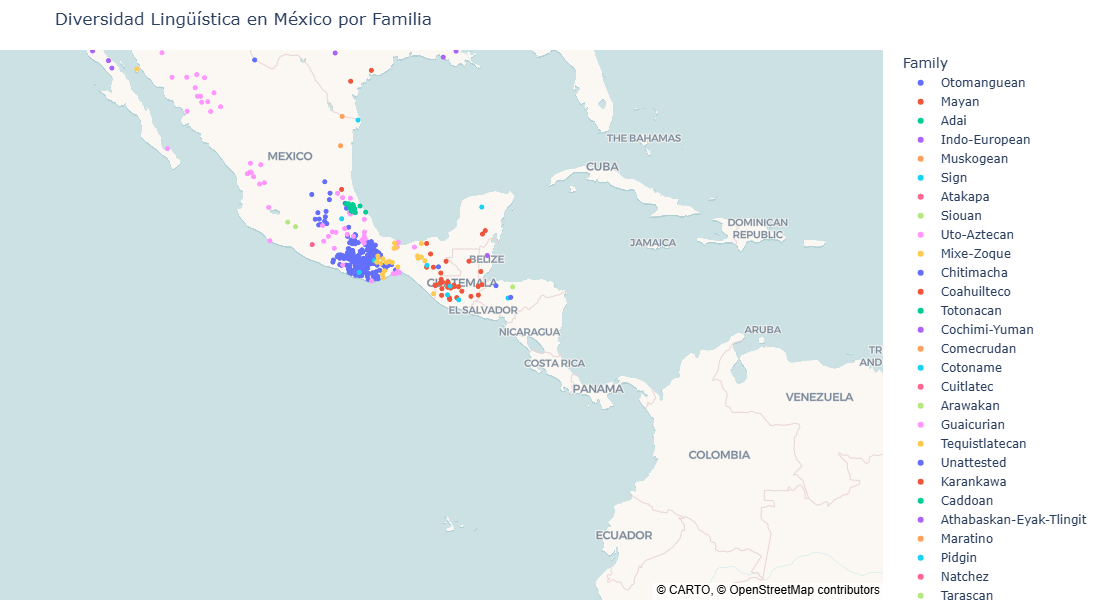

In [29]:
import plotly.express as px

# Obtener el centro aproximado de México para el mapa
center_lat_mexico = (mexico_languages['latitude'].min() + mexico_languages['latitude'].max()) / 2
center_long_mexico = (mexico_languages['longitude'].min() + mexico_languages['longitude'].max()) / 2

# Crear el mapa para México
fig_mexico = px.scatter_map(
    df, # DataFrame ya filtrado y con la columna 'Family'
    lat="latitude",
    lon="longitude",
    color="Family", # Colorea los puntos por familia lingüística
    zoom=4, # Ajusta el nivel de zoom inicial
    height=600,
    title="Diversidad Lingüística en México por Familia"
)

fig_mexico.update_layout(
    mapbox_style="open-street-map", # Estilo de mapa base
    mapbox_center_lat=center_lat_mexico,
    mapbox_center_lon=center_long_mexico,
    margin={"r":0,"t":50,"l":0,"b":0} # Ajusta los márgenes
)

fig_mexico.show()

In [30]:
#Aplicamos las funciones ahora para italia para ver su diversidad linguistica
#Esta se encuentra en las cordenadas de latitud 47-35.29 y longitud 18.3-6.3
#(positivo por ser en el este)
# Mejorar estas coordenadas
min_lat2 = 35.36
max_lat2 = 44.25
min_long2 = 6.61492
max_long2 = 18.3467

italy_languages = languages[
    (languages["latitude"] >= min_lat2)
    & (languages["latitude"] <= max_lat2)
    & (languages["longitude"] >= min_long2)
    & (languages["longitude"] <= max_long2)
]

In [31]:
# Aplicamos la función a nuestras lenguas de Italia
italy_languages = italy_languages.copy()
italy_languages["tree"] = italy_languages["glottocode"].apply(reconstruir_linaje)

# Filtramos las que no se pudieron clasificar
df = italy_languages[~italy_languages["tree"].isin(["", "Unclassifiable"])].copy()

# Extraemos la familia lingüística (la primera palabra del linaje)
df["Family"] = df["tree"].str.split().str[0]
df.set_index("glottocode", inplace=True)
df.head()

,name,isocodes,level,macroarea,latitude,longitude,tree,Family
glottocode,,,,,,,,
algh1238,Algherese,NaN,dialect,Eurasia,40.56432,8.328670,Indo-European > Classical Indo-European > Ital...,Indo-European
apul1236,Apulian-Calabrian Greek,NaN,language,Eurasia,40.35000,18.166667,Indo-European > Classical Indo-European > Grae...,Indo-European
arbe1236,Arbëreshë Albanian,aae,language,Eurasia,38.91100,16.716400,Indo-European > Classical Indo-European > Alba...,Indo-European
bosn1245,Bosnian Standard,bos,dialect,Eurasia,43.85900,17.046000,Indo-European > Classical Indo-European > Balt...,Indo-European
camp1261,Campidanese Sardinian,sro,language,Eurasia,39.05660,9.039350,Indo-European > Classical Indo-European > Ital...,Indo-European


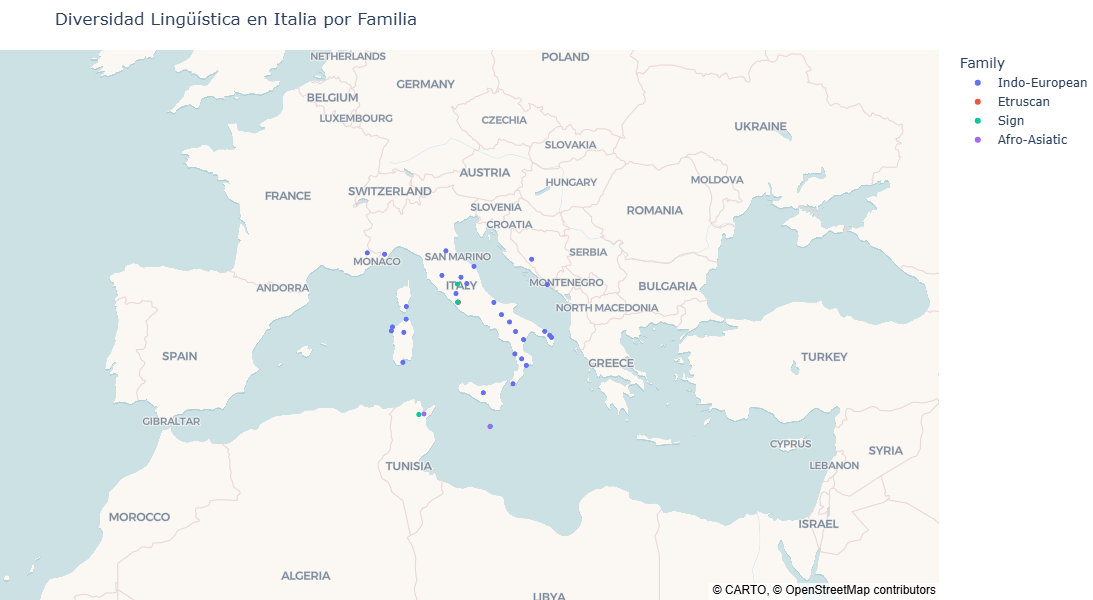

In [32]:
import plotly.express as px


center_lat_italy = (italy_languages['latitude'].min() + italy_languages['latitude'].max()) / 2
center_long_italy = (italy_languages['longitude'].min() + italy_languages['longitude'].max()) / 2


fig_italy = px.scatter_map(
    df, # DataFrame ya filtrado y con la columna 'Family'
    lat="latitude",
    lon="longitude",
    color="Family", # Colorea los puntos por familia lingüística
    zoom=3.5, # Ajusta el nivel de zoom inicial
    height=600,
    title="Diversidad Lingüística en Italia por Familia"
)

fig_italy.update_layout(
    mapbox_style="carto-positron", # Estilo de mapa base
    mapbox_center_lat=center_lat_italy,
    mapbox_center_lon=center_long_italy,
    margin={"r":0,"t":50,"l":0,"b":0} # Ajusta los márgenes
)

fig_italy.show()

### La diversidad de ambos paises

Como podemos observar la diversidad linguistica de México es mucho mayor a la de italia, con más lenguas y familias siendo a su vez también más lenguas o dialectos por familia y región, mientras que itallia mantiene únicamente 4 familias con la más prominente siendo  la indo.europea y con una dispersión mayor por región mientras que la concentración de lenguas por región en México es mucho mayor.


Respecto a la región con mayor diversidad podría facilmente como vemos ser parte del centro y sur-oeste del país con mayor diversidad de familias desde el centro a la parte colindante con guatemala, si bien existen fmailias muy presentes y dominantes dentro de la región existen muchas otras alrededor extendiendosé por toda la región y conviviento varias de ellas dentro de las mismas regiones

### REFERENCIAS
1.- Riaz, A. (2023, January 30). Cómo convertir el diccionario Python en Pandas DataFrame. Delft Stack. https://www.delftstack.com/es/howto/python-pandas/how-to-convert-python-dictionary-to-pandas-dataframe/

2.- elotl. (2025, March 5). PyPI. https://pypi.org/project/elotl/

3.- Resuelto:7.- ¿Cuáles son las coordenadas geográficas extremas de México según el mapa?
A) Longitud. (2025, May 20). Gauth. https://mx.gauthmath.com/solution/1832600210452498/7-Cu-les-son-las-coordenadas-geogr-ficas-extremas-de-M-xico-seg-n-el-mapa-A-Long

4.- Martínez, F. (2023, January 31). Ubicación Geográfica de México: Mapa y coordenadas geográficas. paratodomexico.com. https://paratodomexico.com/geografia-de-mexico/ubicacion-geografica.html

5.- Glottolog 5.3 -. (s. f.). https://glottolog.org/meta/downloads

6.- colaboradores de Wikipedia. (2025, September 23). Geografía de Italia. Wikipedia, La Enciclopedia Libre. https://es.wikipedia.org/wiki/Geograf%C3%ADa_de_Italia

7.- ¿Qué es Plotly en Python y cómo se utiliza? (2025, June 9). Glarity. https://askai.glarity.app/es/search/%C2%BFQu%C3%A9-es-Plotly-en-Python-y-c%C3%B3mo-se-utiliza

8.- coordinates-converter.com. (n.d.). Coordenadas italia con convertidor a todos los sistemas de coordenadas | UTM, WSG. . . Online-Umrechner in Alle Gängigen Koordinatensysteme Wie UTM, WGS, WGS84 Und CH1903, Gauss-Krueger Mit Grosser Karte. https://coordinates-converter.com/es/search/Italia

9.- mapbox. (n.d.). PyPI. https://pypi.org/project/mapbox/